In [ ]:
# ==========================================
# CELL INVESTIGASI: CEK UNIK SEVERITY & DUPLIKASI
# ==========================================
import pandas as pd

file_path = "../../../data/dataset_tiket_lengkap.csv" 
df_cek = pd.read_csv(file_path, sep='|', on_bad_lines='skip')

print("🔍 === HASIL INVESTIGASI DATASET === 🔍\n")

# 1. Cek Distribusi dan Nama Kelas Severity
print("📊 1. DISTRIBUSI KELAS 'SEVERITY'")
print("-" * 30)
distribusi_severity = df_cek['severity'].value_counts(dropna=False)
print(distribusi_severity)
print(f"Total Kelas Unik: {df_cek['severity'].nunique()} kelas\n")

# 2. Cek Duplikasi Teks Keluhan
print("🪞 2. CEK DUPLIKASI DATA")
print("-" * 30)
total_baris = len(df_cek)
duplikat_teks = df_cek.duplicated(subset=['teks_keluhan_awam']).sum()
duplikat_full = df_cek.duplicated().sum()

print(f"Total Baris Data Saat Ini      : {total_baris}")
print(f"Teks Keluhan Sama Persis (WA)  : {duplikat_teks} baris ({(duplikat_teks/total_baris):.1%})")
print(f"Duplikat 100% di Seluruh Kolom : {duplikat_full} baris")

# 3. (Opsional) Intip teks apa saja yang duplikat
if duplikat_teks > 0:
    print("\n⚠️ Contoh teks yang diulang-ulang oleh AI:")
    contoh_duplikat = df_cek[df_cek.duplicated(subset=['teks_keluhan_awam'], keep=False)]
    display(contoh_duplikat[['teks_keluhan_awam', 'severity']].head())

🔍 === HASIL INVESTIGASI DATASET === 🔍

📊 1. DISTRIBUSI KELAS 'SEVERITY'
------------------------------
severity
Sedang    266
Ringan    246
Berat     178
Fatal     108
Name: count, dtype: int64
Total Kelas Unik: 4 kelas

🪞 2. CEK DUPLIKASI DATA
------------------------------
Total Baris Data Saat Ini      : 798
Teks Keluhan Sama Persis (WA)  : 409 baris (51.3%)
Duplikat 100% di Seluruh Kolom : 399 baris

⚠️ Contoh teks yang diulang-ulang oleh AI:


,teks_keluhan_awam,severity
0,AC Cassette rusak parah karena kelembaban ting...,Fatal
1,AC Cassette jebol karena kelembaban tinggi,Fatal
2,"AC Cassette mengalami kerusakan fatal, retak d...",Fatal
3,Kamera CCTV di Gedung Utama lantai 15 zona tim...,Ringan
4,Kamera CCTV overheat karena human error,Ringan


In [ ]:
# ==========================================
# CELL INVESTIGASI: KUALITAS TEKS SEVERITY (LABEL NOISE)
# ==========================================
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd

# Load ulang data mentah terbaru
file_path = "../../../data/dataset_tiket_lengkap_revisi.csv" 
df_investigasi = pd.read_csv(file_path, sep='|', on_bad_lines='skip').dropna(subset=['teks_keluhan_awam', 'severity'])

print("🔍 === OPERASI BEDAH KUALITAS DATA SEVERITY === 🔍\n")

# 1. UJI MATA TELANJANG (Random Sampling)
print("👁️ 1. UJI MATA TELANJANG (Membaca Teks Asli)")
print("Apakah teks di kelas Fatal benar-benar terdengar gawat darurat?")
print("-" * 50)
kelas_severity = ['Ringan', 'Sedang', 'Berat', 'Fatal']

for sev in kelas_severity:
    print(f"\n>>> 3 Contoh Acak Kelas [{sev.upper()}]:")
    # Ambil sampel acak, antisipasi jika datanya kurang dari 3
    sampel = df_investigasi[df_investigasi['severity'] == sev]['teks_keluhan_awam']
    if len(sampel) > 0:
        for i, teks in enumerate(sampel.sample(min(3, len(sampel)))):
            print(f"  {i+1}. \"{teks}\"")
    else:
        print("  (Tidak ada data)")

# 2. UJI DISTRIBUSI KATA (Top N-Grams)
print("\n📊 2. UJI KOSAKATA (Top Kata Paling Sering Muncul per Kelas)")
print("Jika kata di kelas 'Fatal' sama persis dengan kelas 'Ringan', maka dataset ini SAMPAH.")
print("-" * 50)

# Fungsi bantuan untuk mencari kata terbanyak (mengabaikan kata hubung biasa)
def get_top_words(corpus, n=5):
    vec = CountVectorizer(max_features=1000, stop_words=['di', 'ke', 'dan', 'ini', 'itu', 'yang', 'tolong', 'mas', 'pak', 'ada']).fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0) 
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key = lambda x: x[1], reverse=True)
    return words_freq[:n]

for sev in kelas_severity:
    korpus = df_investigasi[df_investigasi['severity'] == sev]['teks_keluhan_awam'].astype(str)
    if len(korpus) > 0:
        top_kata = get_top_words(korpus, 5)
        kata_saja = [kata[0] for kata in top_kata]
        print(f"🔹 Top 5 kata di [{sev.upper()}]: {kata_saja}")

🔍 === OPERASI BEDAH KUALITAS DATA SEVERITY === 🔍

👁️ 1. UJI MATA TELANJANG (Membaca Teks Asli)
Apakah teks di kelas Fatal benar-benar terdengar gawat darurat?
--------------------------------------------------

>>> 3 Contoh Acak Kelas [RINGAN]:
  1. "tekanan APAB Dry Powder bermasalah karena getaran, kadang-kadang macet"
  2. "Lampu di dinding gedung servis lantai 2 zona tengah rusak dan tidak menarik karena kerusakan tampilan yang disebabkan oleh faktor lingkungan"
  3. "Remote kitchen sink tidak berfungsi karena aus normal, mengganggu rutinitas"

>>> 3 Contoh Acak Kelas [SEDANG]:
  1. "Tampilan LAN di Gedung A Lantai 3 Zona Selatan mengalami kerusakan dan sering aus"
  2. "Koneksi internet sering terputus karena debu di jaringan"
  3. "Lemari di lantai 8 zona timur gedung C mengalami getaran yang mengganggu rutinitas"

>>> 3 Contoh Acak Kelas [BERAT]:
  1. "Pintu kayu bocor parah karena kualitas material yang buruk"
  2. "Ground water tank tidak berfungsi karena sensor error, kemungk

📥 1. Memuat dataset dari folder...
🔄 2. Memulai Feature Engineering (Waktu & Biaya)...


C:\Users\ryama\AppData\Local\Temp\ipykernel_21524\2608098430.py:35: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df_eda[kol] = pd.to_datetime(df_eda[kol], errors='coerce')


🧠 3. Target Encoding untuk Kolom Teks (Kategori, Kerusakan, dll)...
🧮 4. Menghitung Matriks Korelasi Keseluruhan...
🎨 5. Menggambar The Ultimate Heatmap...
✅ Selesai! Silakan analisis hasilnya.


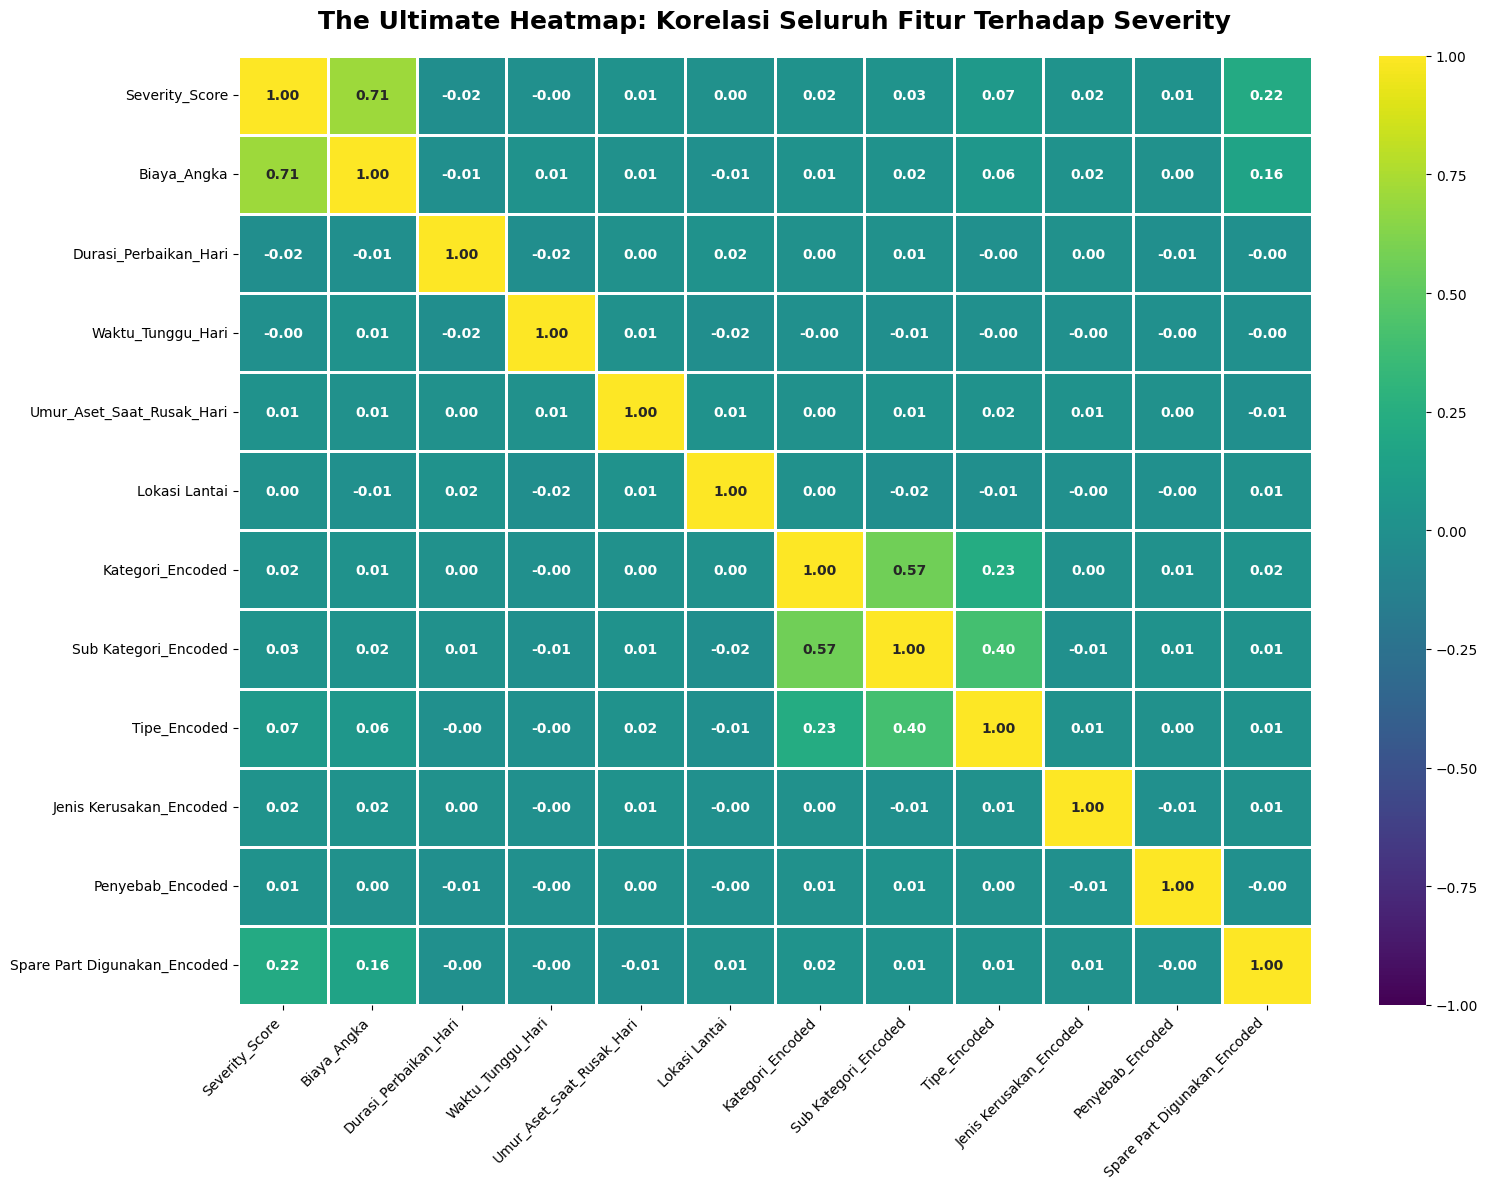

In [ ]:
# ==========================================
# CELL EDA: THE ULTIMATE HEATMAP (ALL FEATURES + TEXT COLUMNS)
# ==========================================
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

print("📥 1. Memuat dataset dari folder...")
# Sesuaikan path dengan lokasi file Anda
path_perbaikan = "../../../data/aset_komplain_enriched.xlsx" 
path_aset = "../../../data/master_aset_enriched.xlsx"                  

df_perbaikan = pd.read_excel(path_perbaikan)
df_aset = pd.read_excel(path_aset)

print("🔄 2. Memulai Feature Engineering (Waktu & Biaya)...")

# Gabungkan data untuk mengambil Tanggal Instalasi & Lokasi Lantai
df_eda = pd.merge(
    df_perbaikan, 
    df_aset[['ID', 'Tanggal Instalasi', 'Lokasi Lantai']], 
    left_on='ID Aset', 
    right_on='ID', 
    how='left'
)

# A. ENCODING TARGET UTAMA (Severity ke Angka 1-4)
severity_map = {'Ringan': 1, 'Sedang': 2, 'Berat': 3, 'Fatal': 4}
df_eda['Severity_Score'] = df_eda['Severity'].map(severity_map)

# B. FEATURE ENGINEERING WAKTU (Hari)
kolom_waktu = ['Tanggal Pengerjaan', 'Tanggal Selesai', 'Tanggal Perencanaan', 'Tanggal Instalasi']
for kol in kolom_waktu:
    df_eda[kol] = pd.to_datetime(df_eda[kol], errors='coerce')

df_eda['Durasi_Perbaikan_Hari'] = (df_eda['Tanggal Selesai'] - df_eda['Tanggal Pengerjaan']).dt.days
df_eda['Waktu_Tunggu_Hari'] = (df_eda['Tanggal Pengerjaan'] - df_eda['Tanggal Perencanaan']).dt.days
df_eda['Umur_Aset_Saat_Rusak_Hari'] = (df_eda['Tanggal Pengerjaan'] - df_eda['Tanggal Instalasi']).dt.days

# C. BERSIHKAN BIAYA PERBAIKAN
if df_eda['Biaya Perbaikan'].dtype == 'object':
    df_eda['Biaya_Angka'] = df_eda['Biaya Perbaikan'].astype(str).str.replace(r'[^\d]', '', regex=True)
    df_eda['Biaya_Angka'] = pd.to_numeric(df_eda['Biaya_Angka'], errors='coerce')
else:
    df_eda['Biaya_Angka'] = df_eda['Biaya Perbaikan']


print("🧠 3. Target Encoding untuk Kolom Teks (Kategori, Kerusakan, dll)...")
# D. SULAP KOLOM TEKS JADI ANGKA (Target Encoding)
kolom_teks = [
    'Kategori', 
    'Sub Kategori', 
    'Tipe', 
    'Jenis Kerusakan', 
    'Penyebab', 
    'Spare Part Digunakan'
]

for kol in kolom_teks:
    if kol in df_eda.columns:
        # Hitung rata-rata Severity untuk setiap kategori unik di kolom tersebut
        mean_encode = df_eda.groupby(kol)['Severity_Score'].mean()
        # Petakan kembali angka tersebut ke DataFrame
        df_eda[kol + '_Encoded'] = df_eda[kol].map(mean_encode)


print("🧮 4. Menghitung Matriks Korelasi Keseluruhan...")

# Kumpulkan semua kolom yang sudah berupa angka
kolom_final = [
    'Severity_Score', 
    'Biaya_Angka', 
    'Durasi_Perbaikan_Hari', 
    'Waktu_Tunggu_Hari', 
    'Umur_Aset_Saat_Rusak_Hari',
    'Lokasi Lantai'
] + [kol + '_Encoded' for kol in kolom_teks if kol in df_eda.columns]

# Hitung Korelasi
df_korelasi = df_eda[kolom_final].corr(method='pearson')

print("🎨 5. Menggambar The Ultimate Heatmap...")

# PLOTTING
# Ukuran kanvas diperbesar karena kolomnya sangat banyak
plt.figure(figsize=(16, 12)) 

sns.heatmap(
    df_korelasi, 
    annot=True, 
    cmap='viridis',      # Menggunakan warna Viridis agar lebih profesional
    fmt=".2f", 
    vmin=-1, vmax=1, 
    linewidths=1, 
    linecolor='white',
    annot_kws={"size": 10, "weight": "bold"}
)

plt.title('The Ultimate Heatmap: Korelasi Seluruh Fitur Terhadap Severity', fontsize=18, pad=20, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)

print("✅ Selesai! Silakan analisis hasilnya.")
plt.tight_layout()
plt.show()